# Task 3 — Self-Attention and Why RNNs Died

### 1. The Sequential Processing Bottleneck
While sequence attention solved the information bottleneck, traditional architectures were still built on top of **RNNs, LSTMs, or GRUs**. These models process text sequentially (word-by-word), creating a severe computational limit:

- **No Parallelization**: To compute the hidden state at step $t$ ($h_t$), you must wait for the computation of the previous step ($h_{t-1}$). Consequently, GPUs cannot process the sequence in parallel during training.
- **Information Mismatch**: Long range dependencies must still travel through sequential links, raising memory limits.

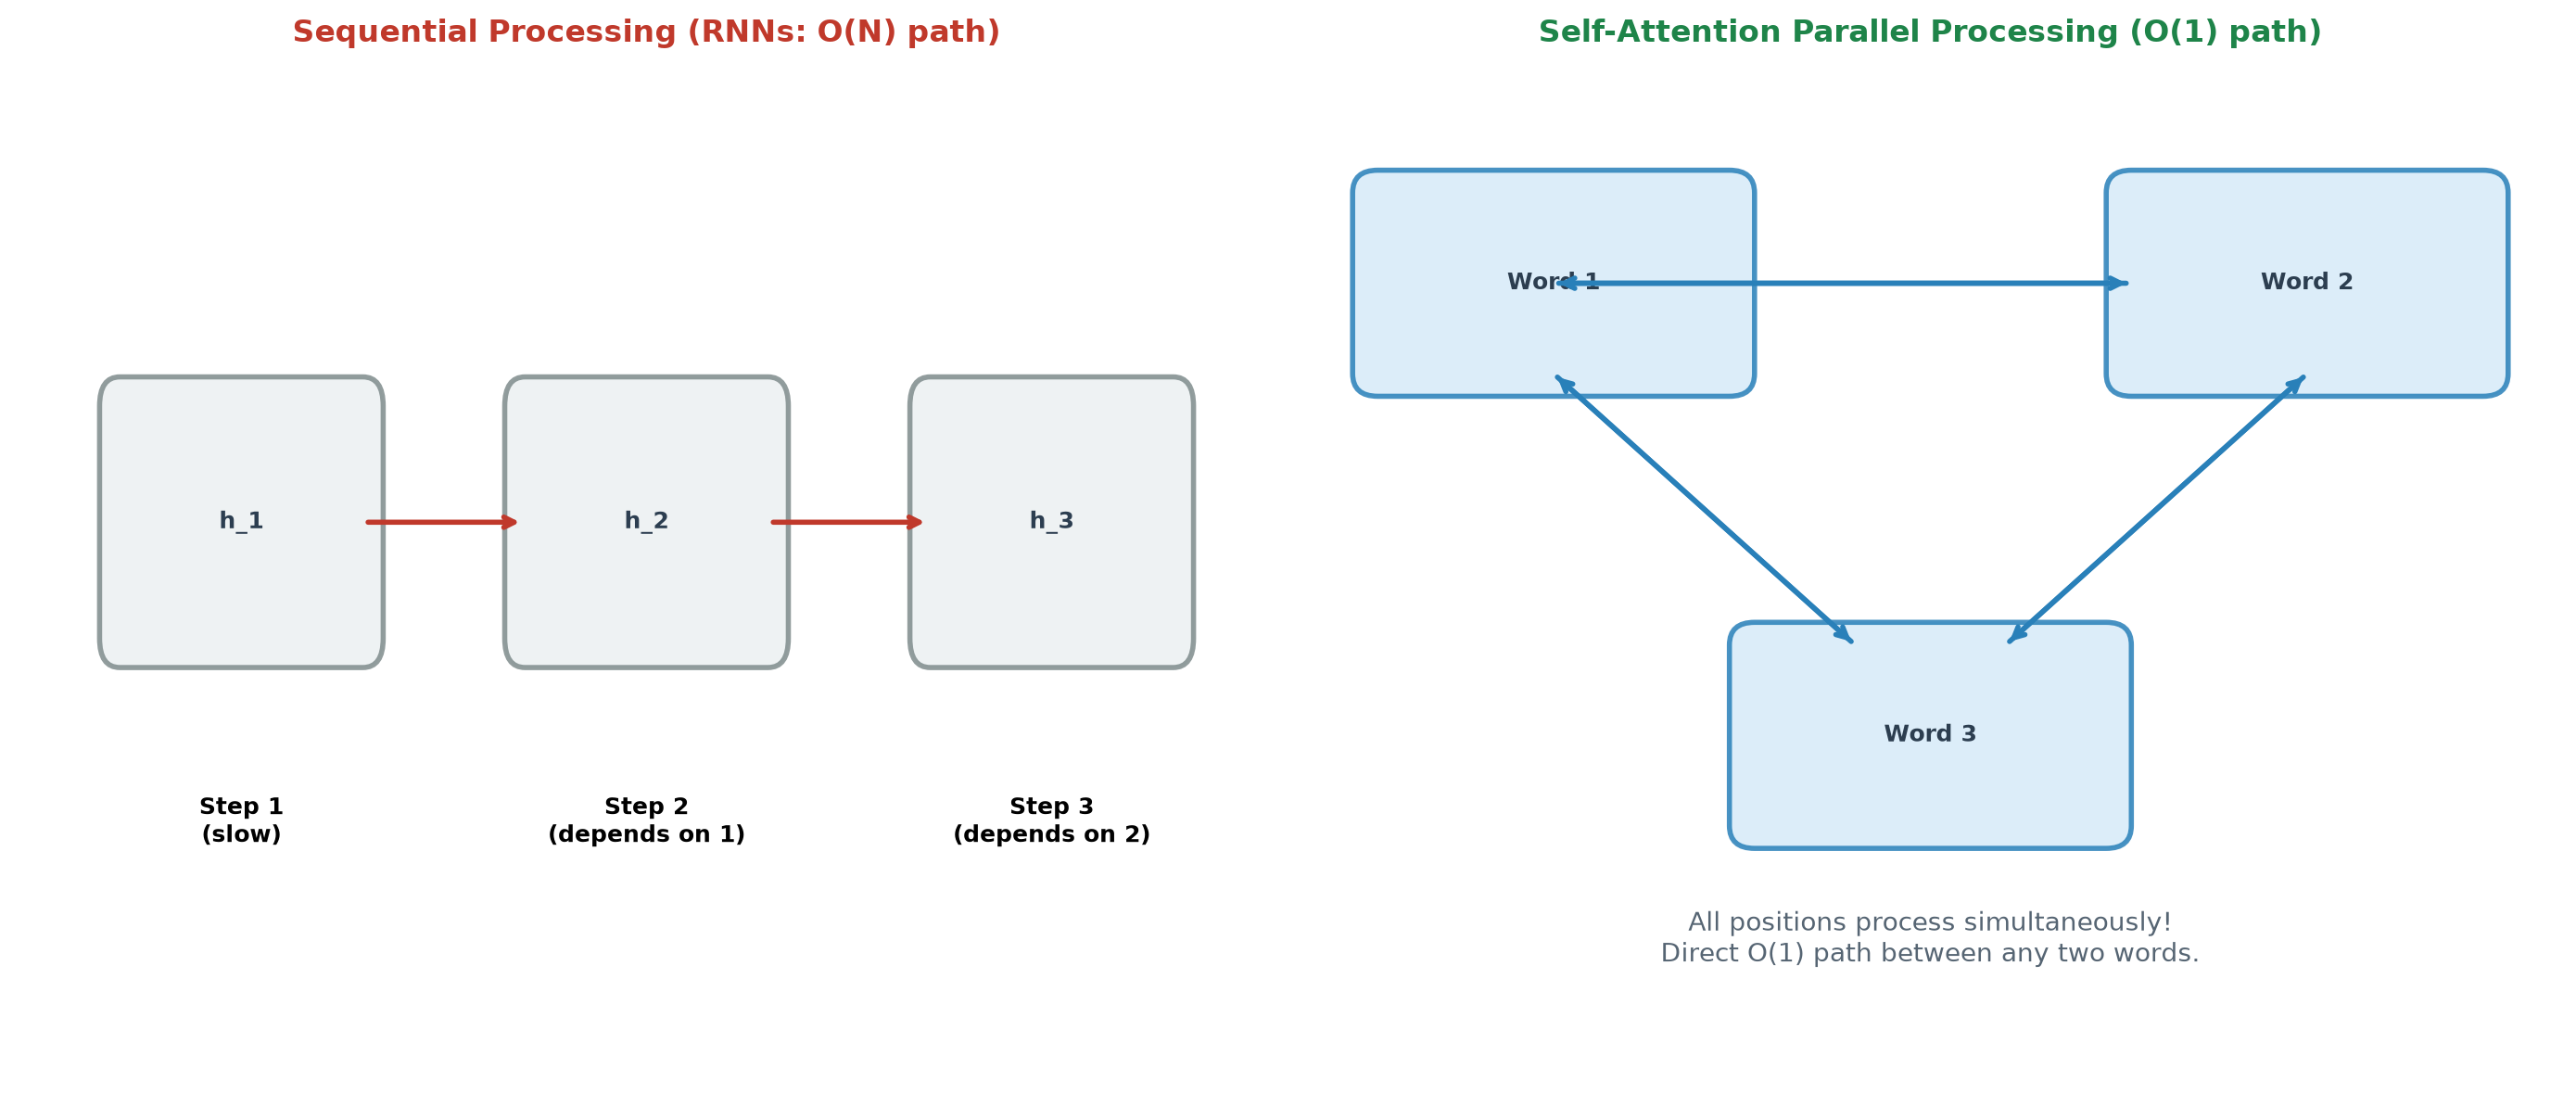

---

### 2. What is Self-Attention?
In 2017, Vaswani et al. introduced **Self-Attention** in the paper *Attention Is All You Need*. Instead of aligning encoder states with decoder states, self-attention allows a single sequence to *attend to itself* to learn internal relationships.

For any input sentence, we project each word embedding into three vectors: Query ($Q$), Key ($K$), and Value ($V$) using learnable weight matrices ($W_Q, W_K, W_V$). Every word in the sentence is then compared against all other words in the sentence simultaneously. This allows the model to capture syntax and relationships immediately in a single step ($O(1)$ path length), rather than sequentially ($O(N)$ path length).

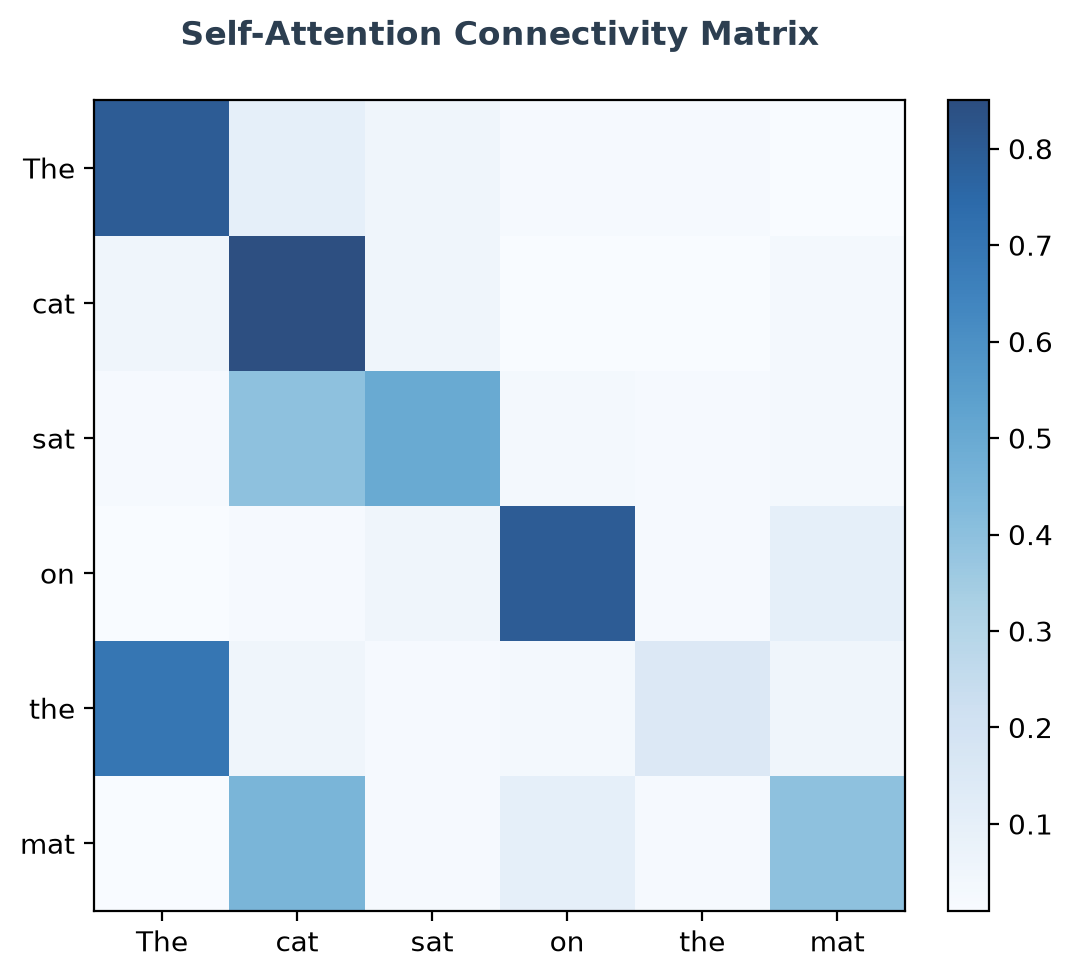

---

### 3. Positional Encoding
Because self-attention replaces sequential loops with set-like parallel matrix operations, it is inherently **order-agnostic**. The model treats the sentence "The cat ate the mouse" identically to "The mouse ate the cat".

To preserve word order, we must inject position details back into word embeddings. The Transformer achieves this using **Positional Encodings** — static sinusoidal patterns added directly to input embeddings:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

This mapping allows the model to recognize where words reside in the sequence by interpreting the frequency phase of the waves.

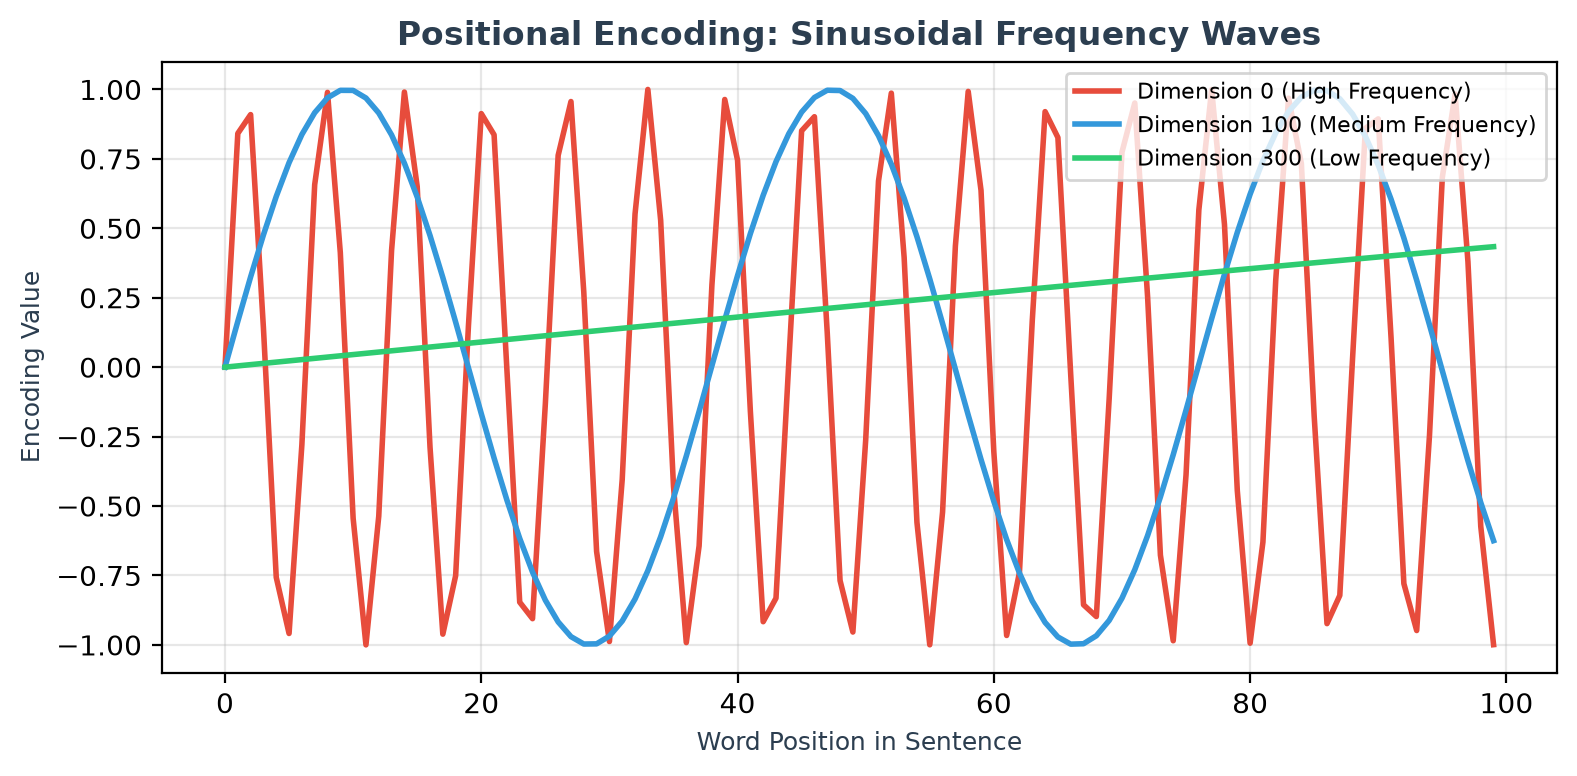
